# Diputrax V12 — Búsqueda de la segmentación temporal óptima (LR Lasso)

**Pregunta central de este cuaderno:**

> **¿Cuál es la división de segmentos de tiempo (agrupación de legislaturas) que minimiza el sesgo y la varianza mientras maximiza la capacidad predictiva y la validez estructural, con un modelo de regresión logística con regularización Lasso?**

**Objeto.** Los datos cubren diez legislaturas de la Cámara de Diputados de México (LVII–LXVI, 1997–presente; ~5,000 registros, una fila por diputado-legislatura). Tres targets se modelan de forma independiente: `nodal_bin` (recibió ≥1 comisión nodal), `lastre_bin` (recibió ≥1 comisión lastre) y `n_comisiones_tematicas` (conteo de comisiones temáticas). El mecanismo de asignación de comisiones cambia a lo largo del tiempo, así que cualquier modelo debe decidir **qué tramos del tiempo se modelan juntos**. Este cuaderno trata esa decisión como un problema de optimización: define un espacio de seis segmentaciones candidatas —del modelo único al modelo por legislatura— y las evalúa bajo criterios explícitos, sin privilegiar a ninguna a priori.

**Estructura.** La sección 1 plantea el problema (intercambio sesgo-varianza) y operacionaliza los cuatro criterios de decisión. Las secciones 2–3 describen datos, pipeline y el espacio de candidatos. La sección 4 define el protocolo de evaluación comparable entre segmentaciones (predicciones *out-of-fold* sobre estratos fijos por legislatura) y la sección 5 justifica los métodos y fija la regla de decisión. Las secciones 6–7 reportan la capacidad predictiva (AUC para los targets binarios; MAE para el conteo). La sección 8 mide la validez estructural (similitud de coeficientes entre legislaturas). La sección 9 aplica la regla de decisión y emite el veredicto.

**Ejecución.** El cuaderno es autocontenido y corre de principio a fin: imputación MICE de `edad_al_tomar_cargo` → *feature engineering* (61 features) → `LogisticRegression` L1 (+`SelectFromModel` en el modelo principal), validación cruzada estratificada *k*=5 con `random_state=42` en todas las particiones.

**Nota de entorno.** Solo requiere `scikit-learn`, `pandas`, `numpy`, `matplotlib` y `seaborn`: la pregunta es de **comparación de segmentaciones temporales**, no de interpretación de features individuales ni de inferencia bayesiana.

# 1. El problema — segmentar el tiempo es un intercambio sesgo-varianza

Modelar los diez ciclos legislativos exige decidir qué filas entran juntas al entrenamiento. Los dos extremos del espectro fallan por razones opuestas:

- **Un solo modelo para todo el periodo** (máxima muestra, n=5,000) asume que el mecanismo de asignación es estable durante casi tres décadas. Si no lo es, el modelo estima un **promedio de regímenes distintos** que no corresponde a ningún periodo real: **sesgo** de especificación, invisible en el AUC agregado pero fatal para los coeficientes.
- **Un modelo por legislatura** (máxima homogeneidad, n≈500) no mezcla regímenes, pero estima 61 coeficientes con muestras diez veces menores: **varianza** Esto genera coeficientes y métricas inestables, sensibles al reparto de folds y a la semilla.

Toda segmentación intermedia es un punto en ese intercambio. La pregunta del cuaderno es qué punto lo resuelve mejor.

## 1.1 Criterios de decisión y su operacionalización

| Criterio | Qué significa aquí | Métrica que lo operacionaliza | Dónde |
|---|---|---|---|
| **Minimizar sesgo** | No mezclar en un grupo periodos con lógicas de asignación distintas | Heterogeneidad interna de los grupos (AUC *naive* por subgrupo) y similitud de coeficientes *dentro* de grupo | §6, §8 |
| **Minimizar varianza** | No estimar con muestras tan pequeñas que el resultado sea ruido | Desviación estándar de la CV por grupo; estabilidad de los coeficientes L1 con n pequeña | §6, §8 |
| **Maximizar capacidad predictiva** | Ordenar mejor a los diputados dentro de cada legislatura, sin crédito por tasas base | **AUC *out-of-fold* ponderado por estrato-legislatura** (`Pond. legis`); MAE ponderado para el conteo | §6, §7 |
| **Maximizar validez estructural** | Que las fronteras caigan donde de verdad cambia la lógica de asignación | **Δ = similitud coseno media dentro − entre grupos** de los coeficientes por legislatura | §8 |

Sesgo y varianza no son criterios independientes de los otros dos: son los **mecanismos** que explican por qué una segmentación gana o pierde capacidad predictiva y validez estructural. Las secciones 6–8 los diagnostican por separado para que el veredicto de §9 pueda atribuir cada resultado a su causa.

## 1.2 Construcción del espacio de candidatos

El espacio de búsqueda (sección 3) recorre la granularidad completa —1, 2, 3, 4, 5 y 10 grupos— y contiene dos familias:

- **Cortes políticos**: fronteras en años electorales que cambiaron la coalición dominante de la Cámara (2006, 2015, 2018, 2024). La asignación de comisiones la negocia la Junta de Coordinación Política y la controla, en la práctica, la coalición mayoritaria de cada ciclo; si el mecanismo cambia, es plausible que cambie en esas fronteras.
- **Cortes mecánicos**: ventanas uniformes de dos legislaturas, ciegas a la política. Sirven de control: si rinden igual que los cortes políticos a granularidad comparable, la ubicación de las fronteras sería irrelevante y solo importaría el tamaño de grupo.

Ningún candidato se privilegia a priori: los seis se evalúan con el mismo espacio de features, el mismo modelo, la misma semilla y la misma vara (§4).

## 1.3 Regla de decisión (resumen; formalizada en §5.7)

1. La **capacidad predictiva estratificada** (`Pond. legis`) es la métrica principal; diferencias por debajo del error de estimación (≈±0.02 por estrato con estas n) se tratan como **empate**.
2. Entre candidatos empatados en predicción decide la **validez estructural** (Δ), leída como contraste entre familias —no como ranking fino, cuya inestabilidad el propio cuaderno documenta (§8).
3. Los diagnósticos de **sesgo** (heterogeneidad interna) y **varianza** (n por grupo, dispersión de CV) desempatan y explican. En la interpretacion un candidato que gana por fuerza muestral prestada (masking), o que esconde regímenes distintos dentro de un grupo, recibe el descuento correspondiente en la lectura final.

# 2. Datos, imputación y pipeline de modelado

Pipeline autocontenido: carga del parquet → imputación MICE de `edad_al_tomar_cargo` → *feature engineering* (61 features) → *model factories* (LR L1, LR L1+`SelectFromModel`, GLM Poisson). Todas las particiones usan `random_state=42`.

In [1]:
import warnings, io, os
warnings.filterwarnings("ignore")
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "4")  # evita warning wmic de joblib/loky en Windows 11

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display

from sklearn.model_selection import (
    StratifiedKFold, KFold, cross_val_score, cross_val_predict,
)
from sklearn.metrics import roc_auc_score, mean_absolute_error
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectFromModel
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, PoissonRegressor
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer

sns.set_style("whitegrid")
pd.set_option("display.float_format", "{:.3f}".format)
print("Imports OK")

Imports OK


In [2]:
# --- Constantes del pipeline ---
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PARQUET = PROJECT_ROOT / "data" / "clean" / "diputados_20260421_205712.parquet"

# Mapeo auxiliar de 4 grupos por coalición dominante (lo consume get_groups, AC2)
COAL4_MAP = {
    57: "G1_PRI_57_59",  58: "G1_PRI_57_59",  59: "G1_PRI_57_59",
    60: "G2_PAN_60_62",  61: "G2_PAN_60_62",  62: "G2_PAN_60_62",
    63: "G3_TRANS_63_65", 64: "G3_TRANS_63_65", 65: "G3_TRANS_63_65",
    66: "G4_MOR_66",
}
TOP_PARTIDOS = ["PRI", "PAN", "MORENA", "PRD", "PVEM", "PT", "MC"]
LEGIS = list(range(57, 67))

raw = pd.read_parquet(PARQUET)
print(f"Shape: {raw.shape}")

Shape: (5000, 79)


In [3]:
# --- Imputación MICE de edad_al_tomar_cargo ---
_MICE_COND_VARS = [
    'legislatura_num', 'n_cargos_legislativos_prev',
    'fue_diputado_local', 'fue_diputado_federal', 'fue_senador',
    'n_trayectoria_legislativa', 'n_trayectoria_admin', 'nivel_cargo_max',
    'fue_presidente_mun', 'fue_secretario_cargo', 'fue_director_general',
    'fue_subsecretario', 'admin_en_gobierno_fed', 'admin_en_gobierno_est',
    'admin_en_gobierno_mun', 'edad_al_tomar_cargo',
]
_mice_cols = [c for c in _MICE_COND_VARS if c in raw.columns]
_mice_imputer = IterativeImputer(max_iter=10, random_state=42,
                                 initial_strategy='mean', skip_complete=True)
_mice_df = pd.DataFrame(_mice_imputer.fit_transform(raw[_mice_cols].copy()),
                        columns=_mice_cols, index=raw.index)

raw['edad_missing'] = raw['edad_al_tomar_cargo'].isna().astype(int)
raw['edad_imp'] = np.where(
    raw['edad_al_tomar_cargo'].isna(),
    _mice_df['edad_al_tomar_cargo'].clip(18, 90),
    raw['edad_al_tomar_cargo'],
)
print(f"MICE OK — N imputados: {int(raw['edad_missing'].sum())}, "
      f"media edad_imp: {raw['edad_imp'].mean():.2f}")

MICE OK — N imputados: 510, media edad_imp: 45.98


In [4]:
# --- Feature engineering ---
df = raw.copy()
df["grupo4"] = df["legislatura_num"].map(COAL4_MAP)

# Targets: nodal_bin, lastre_bin, n_comisiones_tematicas
df["nodal_bin"]  = (df["n_comisiones_nodales"] >= 1).astype(int)
df["lastre_bin"] = (df["n_comisiones_lastre"]  >= 1).astype(int)

REGION_MAP = {
    "CDMX": "CDMX",
    **dict.fromkeys(["MEX","HGO","MOR","PUE","TLAX","QRO","GTO","AGS"], "CENTRO"),
    **dict.fromkeys(["VER","OAX","CHIS","TAB","GRO","CAM","YUC","QROO"], "SUR"),
    **dict.fromkeys(["NL","TAMPS","COAH","CHIH","SON","BC","BCS","SIN",
                     "DGO","ZAC","SLP","NAY"], "NORTE"),
    **dict.fromkeys(["JAL","COL","MICH"], "OCCIDENTE"),
    "DESCONOCIDO": "RP",
}
df["region"]      = df["entidad_codigo"].map(REGION_MAP).fillna("CENTRO")
df["partido_cat"] = df["partido"].where(df["partido"].isin(TOP_PARTIDOS), "OTRO")
df["univ_elite"]  = df[["acad_unam","acad_itam","acad_ibero","acad_itesm"]].max(axis=1)
df["sexo_bin"]    = (df["sexo"] == "M").astype(int)

_p    = pd.get_dummies(df["partido_cat"],    prefix="p")
_reg  = pd.get_dummies(df["region"],         prefix="reg")
_area = pd.get_dummies(df["area_formacion"], prefix="area")
df_enc = pd.concat([df, _p, _reg, _area], axis=1)

print("Feature engineering OK")
print("\nTasas de los targets por legislatura:")
display(df.groupby("legislatura_num")[["nodal_bin","lastre_bin","n_comisiones_tematicas"]]
          .mean().round(3))

Feature engineering OK

Tasas de los targets por legislatura:


,nodal_bin,lastre_bin,n_comisiones_tematicas
legislatura_num,,,
57,0.280,0.364,1.338
58,0.334,0.432,1.522
59,0.352,0.466,1.732
60,0.394,0.420,1.774
61,0.408,0.432,1.776
62,0.420,0.526,2.232
63,0.442,0.488,2.150
64,0.466,0.478,2.016
65,0.578,0.530,2.272


**Tasas base de los targets por legislatura.** La tabla muestra la prevalencia de valores positivos en cada variable objetivo en cada una de las diez legislaturas. Se observa que la proporción de diputados con **comisión nodal** sube a lo largo de la serie (0.280 en la LVII → 0.554 en la LXVI, con máximo de 0.578 en la LXV). Esto indica que acceder a una comisión estratégica se ha vuelto progresivamente más común. El **lastre** se mueve entre ~0.36 y ~0.53 y cae a 0.392 en la LXVI. Las **temáticas** (conteo medio) alcanzan su máximo en la segunda mitad de la serie.

*Relevancia para el análisis.* Dos consecuencias. (1) Los cambios en las tasas base sugiere **heterogeneidad temporal**, es decir, que las legislaturas no son muestras intercambiables de una misma población lo que confirma la necesidad de segmentar de *algún* modo los periodos de tiempo. (2) Esto indica que la evaluación posterior debe **estratificarse** ya que un modelo agrupado podría inflar su AUC solo por explotar estas diferencias de prevalencia entre periodos (§4, §5.2), sin aprender nada del diputado individual.

In [5]:
# --- Espacio de features (61 columnas) ---
NUMERIC_FEATS = [
    "sexo_bin", "edad_imp", "edad_missing",
    "mayoria_relativa", "es_partido_mayoria", "legislatura_num",
    "grado_estudios_ord", "tiene_posgrado", "tiene_doctorado",
    "estudios_en_extranjero", "univ_publica", "univ_privada",  # AC1: univ_extranjera eliminada — duplicado exacto (r=1.0)
    "univ_elite",
    # AC1: n_cargos_legislativos_prev eliminada — = fue_diputado_local+fue_diputado_federal+fue_senador (combinacion lineal exacta)
    "fue_diputado_local",
    "fue_diputado_federal", "fue_senador", "n_trayectoria_legislativa",
    "n_trayectoria_admin", "nivel_cargo_max",
    "fue_presidente_mun", "fue_presidente_org", "fue_director_general",
    "fue_secretario_cargo", "fue_subsecretario", "fue_director",
    "fue_coordinador", "fue_delegado", "fue_asesor", "fue_regidor", "fue_sindico",
    "admin_en_partido", "admin_en_sindicato", "admin_en_universidad",
    "admin_en_gobierno_fed", "admin_en_gobierno_est", "admin_en_gobierno_mun",
    "n_trayectoria_politica", "tiene_exp_juvenil",
    "lider_juvenil_partido", "lider_juvenil_gobierno", "miembro_org_juvenil",
    "nivel_liderazgo_juvenil",
    "n_trayectoria_empresarial", "n_investigacion_docencia", "n_organos_gobierno",
]
_AREA_KEEP = ["area_Derecho", "area_Ciencias Políticas y Sociales",
              "area_Económico-Financiera"]
DUMMY_FEATS = list(_p.columns) + list(_reg.columns) + \
              [c for c in _AREA_KEEP if c in df_enc.columns]
FEAT_COLS = NUMERIC_FEATS + DUMMY_FEATS
print(f"Features totales: {len(FEAT_COLS)}  "
      f"(numéricas={len(NUMERIC_FEATS)}, dummies={len(DUMMY_FEATS)})")

Features totales: 62  (numéricas=45, dummies=17)


## Acciones correctivas del pipeline

El espacio de features y la infraestructura de validación incorporan dos correcciones derivadas del diagnóstico de supuestos del pipeline:

- **AC1 — Consolidación de features redundantes.** Se elimina `univ_extranjera` (duplicado exacto de `estudios_en_extranjero`, r=1.0) y `n_cargos_legislativos_prev` (suma exacta de `fue_diputado_local + fue_diputado_federal + fue_senador`, ya incluidos). Son redundancias *dentro del espacio-columna*: el AUC/MAE es invariante a su eliminación; solo se depura la atribución de importancias y los VIF.
- **AC2 — Validación sin fuga por reelección.** Se definen `get_groups()` (por `diputado_id`) y `cv_auc_grouped` / `cv_mae_grouped` (`StratifiedGroupKFold` / `GroupKFold`) para poder estimar el desempeño sin que un mismo diputado reelecto quede en train y test del mismo fold.

**Límite interpretativo:** en periodos de partido dominante `es_partido_mayoria` es casi colineal con la identidad partidista (VIF≈129 en el tramo final de la serie) por lo que se imposibilita cualquier interpretacion causal.

In [6]:
# --- Model factories ---
_L1_PARAMS = dict(l1_ratio=1, solver='liblinear', C=0.1, max_iter=3000,
                  class_weight='balanced', random_state=42)

def lr_binary():
    "LR L1 (Lasso) completo."
    return Pipeline([("sc", StandardScaler()),
                     ("lr", LogisticRegression(**_L1_PARAMS))])

def lr_l1_sfm():
    "scale -> SelectFromModel(L1) -> L1 — modelo principal del cuaderno."
    return Pipeline([
        ("sc",  StandardScaler()),
        ("sfm", SelectFromModel(LogisticRegression(**_L1_PARAMS), threshold="mean")),
        ("lr",  LogisticRegression(**_L1_PARAMS)),
    ])

def lr_poisson():
    "GLM Poisson."
    return Pipeline([("sc", StandardScaler()),
                     ("pr", PoissonRegressor(alpha=1.0, max_iter=3000))])

def cv_auc(model, X, y, k=5):
    cv = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
    s = cross_val_score(model, X, y, cv=cv, scoring="roc_auc")
    return s.mean(), s.std()

# Paleta categórica para los ESQUEMAS (orden fijo, validada CVD)
SCHEME_COLORS = ["#2a78d6", "#1baf7a", "#eda100", "#008300", "#4a3aa7", "#e34948"]
TXT = "#333333"
# -- AC2: validacion sin fuga por reeleccion (agrupada por diputado_id) --
# get_groups usa diputado_id como clave para que un mismo diputado reelecto
# no caiga en train y test del mismo fold (fuga por reeleccion).
from sklearn.model_selection import StratifiedGroupKFold, GroupKFold

def get_groups(group):
    mask = df_enc["grupo4"] == group
    if "diputado_id" in df_enc.columns:
        return df_enc.loc[mask, "diputado_id"].reset_index(drop=True)
    return pd.Series(range(int(mask.sum())))

def cv_auc_grouped(model, X, y, groups, k=5):
    cv = StratifiedGroupKFold(n_splits=k, shuffle=True, random_state=42)
    s = cross_val_score(model, X, y, groups=groups, cv=cv, scoring="roc_auc")
    return s.mean(), s.std()

def cv_mae_grouped(model, X, y, groups, k=5):
    cv = GroupKFold(n_splits=k)
    s = -cross_val_score(model, X, y, groups=groups, cv=cv, scoring="neg_mean_absolute_error")
    return s.mean(), s.std()

print("Pipeline de modelado listo — OK")

Pipeline de modelado listo — OK


# 3. Espacio de candidatos: seis segmentaciones temporales

Para el analisis se plantean seis segmentaciones que recorren el espectro completo de granularidad, del modelo único al modelo por legislatura. Aqui se plantean como dos familias: cortes **políticos** (fronteras en cambios de coalición dominante: 2006, 2015, 2018, 2024) y cortes **mecánicos** (ventanas uniformes). `S2_2018` divide el periodo en dos con un único corte en la elección de 2018 (LVII–LXIII antes; LXIV–LXVI después).

| Esquema | Grupos | Racionalidad |
|---|---|---|
| `S1_POOLED` | 1 (57–66) | Hipótesis nula: mecanismo único y estable; máxima muestra (n=5,000), mínima varianza, máximo sesgo potencial. |
| `S2_2018` | 2 (57–63 / 64–66) | Un solo corte político, en la elección de 2018 que marca el ascenso de Morena. |
| `S3_FUSION34` | 3 (57–59 / 60–62 / 63–66) | Partición de bloques de 3 legislaturas (n = 1500) con un bloque de 4 legislaturas que incluye la supermayoría de Morena; pone a prueba si la LXVI legislatura merece modelo propio o puede unirse a al bloque anterior. Tres cortes de coalición, sin separar el último tramo (63–66 juntos). |
| `S4_ERAS` | 4 (57–59 / 60–62 / 63–65 / 66) | Partición de bloques de 3 legislaturas (n = 1500), con la separacion de la LXVI con la supermayoria de Morena en un grupo aislado. Evalua si la supermayoria de Morena causo cambios en el modelo de reclutamiento. Cuatro cortes de coalición (2006, 2015, 2024); el último grupo es una sola legislatura. |
| `S5_PARES` | 5 (pares consecutivos) | Ventanas uniformes de 2 legislaturas, ciegas a la política: control de la familia mecánica. |
| `S6_LEGIS` | 10 (una por legislatura) | Máxima homogeneidad, mínima muestra (n≈500): el extremo de varianza. |

Todos los candidatos usan **el mismo espacio de 61 features, el mismo modelo (LR L1+SFM) y la misma semilla**; lo único que cambia es qué filas entran juntas al entrenamiento. Nótese que `legislatura_num` está en `FEAT_COLS`: los esquemas gruesos pueden usarla para adaptarse parcialmente al tiempo, lo que hace la comparación *conservadora* a favor de los esquemas gruesos.

In [7]:
# --- Definición de esquemas: legislatura -> grupo ---
SCHEMES = {
    "S1_POOLED": {l: "TODAS_57_66" for l in LEGIS},
    "S2_2018":   {l: ("PRE_2018" if l <= 63 else "POST_2018") for l in LEGIS},
    "S3_FUSION34": {
        **{l: "G1_PRI_57_59" for l in (57, 58, 59)},
        **{l: "G2_PAN_60_62" for l in (60, 61, 62)},
        **{l: "G3_TRANSMOR_63_66" for l in (63, 64, 65, 66)},
    },
    "S4_ERAS": {
        **{l: "G1_PRI_57_59" for l in (57, 58, 59)},
        **{l: "G2_PAN_60_62" for l in (60, 61, 62)},
        **{l: "G3_TRANS_63_65" for l in (63, 64, 65)},
        66: "G4_MOR_66",
    },
    "S5_PARES": {l: f"PAR_{57 + 2*((l-57)//2)}_{58 + 2*((l-57)//2)}" for l in LEGIS},
    "S6_LEGIS": {l: f"LEG_{l}" for l in LEGIS},
}
SCHEME_ORDER = list(SCHEMES.keys())
SCHEME_SHORT = {
    "S1_POOLED": "S1 — Pooled (1 grupo)",
    "S2_2018":   "S2 — Corte 2018 (2 grupos)",
    "S3_FUSION34": "S3 — Fusión T+M (3 grupos)",
    "S4_ERAS":   "S4 — 4 cortes coalición",
    "S5_PARES":  "S5 — Pares uniformes (5)",
    "S6_LEGIS":  "S6 — Por legislatura (10)",
}

# Tabla de composición: n y tasas base por grupo de cada esquema
rows = []
for sch, mapping in SCHEMES.items():
    grp = df_enc["legislatura_num"].map(mapping)
    for g in pd.unique(grp):
        m = grp == g
        rows.append({
            "Esquema": sch, "Grupo": g, "n": int(m.sum()),
            "Tasa nodal": df_enc.loc[m, "nodal_bin"].mean(),
            "Tasa lastre": df_enc.loc[m, "lastre_bin"].mean(),
            "Media temáticas": df_enc.loc[m, "n_comisiones_tematicas"].mean(),
        })
df_schemes = pd.DataFrame(rows)
display(df_schemes.set_index(["Esquema", "Grupo"]).round(3))

n  Tasa nodal  Tasa lastre  Media temáticas
Esquema     Grupo                                                            
S1_POOLED   TODAS_57_66        5000       0.423        0.453            1.868
S2_2018     PRE_2018           3500       0.376        0.447            1.789
            POST_2018          1500       0.533        0.467            2.052
S3_FUSION34 G1_PRI_57_59       1500       0.322        0.421            1.531
            G3_TRANSMOR_63_66  2000       0.510        0.472            2.076
            G2_PAN_60_62       1500       0.407        0.459            1.927
S4_ERAS     G1_PRI_57_59       1500       0.322        0.421            1.531
            G3_TRANS_63_65     1500       0.495        0.499            2.146
            G2_PAN_60_62       1500       0.407        0.459            1.927
            G4_MOR_66           500       0.554        0.392            1.868
S5_PARES    PAR_59_60          1000       0.373        0.443            1.753
            PAR_57_58          1000       0.307        0.398            1.430
            PAR_63_64          1000       0.454        0.483            2.083
            PAR_61_62          1000       0.414        0.479            2.004
            PAR_65_66          1000       0.566        0.461            2.070
S6_LEGIS    LEG_59              500       0.352        0.466            1.732
            LEG_58              500       0.334        0.432            1.522
            LEG_57              500       0.280        0.364            1.338
            LEG_63              500       0.442        0.488            2.150
            LEG_62              500       0.420        0.526            2.232
            LEG_64              500       0.466        0.478            2.016
            LEG_61              500       0.408        0.432            1.776
            LEG_66              500       0.554        0.392            1.868
            LEG_65              500       0.578        0.530            2.272
            LEG_60              500       0.394        0.420            1.774

**Lectura — composición de los candidatos.** La tabla despliega, para cada segmentación, el tamaño muestral (`n`) y las tasas base de cada grupo. Recorre el espectro completo de granularidad: de **S1** (un solo grupo, n=5,000) a **S6** (un grupo por legislatura, n≈500). El grupo más corto del espacio de candidatos es `G4_MOR_66` en **S4**, con **n=500** (una sola legislatura), frente a n=1,500 de sus otros tres grupos.

*Relevancia para el análisis.* La `n` por grupo gobierna directamente la **varianza de los coeficientes y del AUC**: grupos más finos son más homogéneos pero más ruidosos. Comparar segmentaciones es, en el fondo, recorrer el intercambio **sesgo** (mezclar regímenes distintos) contra **varianza** (estimar con poca muestra) planteado en §1. Las tasas base por grupo también anticipan qué particiones funden poblaciones dispares —p. ej., `POST_2018` de S2 (n=1,500) promedia legislaturas con tasas nodales distintas—, algo que la evaluación estratificada y la §8 pondrán a prueba.

# 4. Diseño de evaluación comparable entre esquemas

**El problema (i): comparabilidad.** El AUC de validación cruzada *dentro de cada grupo* no es comparable entre esquemas: cambia la n, cambia la mezcla de poblaciones y, sobre todo, un modelo agrupado puede ganar AUC "gratis" al distinguir entre periodos con tasas base distintas (predecir que un diputado de la LXVI tiene comisión nodal es fácil si la tasa de la LXVI es 0.55 y la global 0.42, sin saber nada del diputado). La solución es evaluar sobre **estratos fijos, idénticos para todos los esquemas**.

**El problema (ii): neutralidad de los estratos.** Los estratos fijos no pueden ser los grupos de ninguno de los candidatos, porque eso usaría la vara de uno para medir a todos. El sesgo es técnico y preciso: estratificar por los grupos de un candidato dado elimina el crédito por tasas base exactamente en *sus* fronteras, pero deja intacto el crédito por diferencias de prevalencia *dentro* de sus grupos, que los candidatos más finos sí pueden explotar. La vara neutral es el **estrato-legislatura**: la legislatura es la unidad mínima de asignación de los 6 esquemas (cada grupo de cada esquema es una unión de legislaturas), es decir, el *refinamiento común más fino* de todos los candidatos. Dentro de un estrato-legislatura no queda periodo alguno que distinguir —ningún esquema puede ganar crédito por tasas base— y las fronteras de los estratos no coinciden con las de ningún candidato en particular.

**El protocolo.** Para cada esquema:

1. Dentro de cada grupo se generan **predicciones *out-of-fold*** con `cross_val_predict` (StratifiedKFold *k*=5, `shuffle=True`, `random_state=42`) — cada diputado recibe una probabilidad predicha por un modelo que **nunca lo vio en entrenamiento**.
2. Al terminar, **los 5,000 diputados tienen una predicción OOF** bajo cada esquema.
3. Las métricas se calculan sobre **los 10 estratos-legislatura fijos, idénticos para todos los esquemas**:
   - **AUC por estrato-legislatura** y su **promedio ponderado por n** (`Pond. legis`) — métrica principal;
   - AUC global (se reporta pero se interpreta con cautela por el efecto de tasas base descrito arriba);
   - la misma ponderación con el modelo LR L1 completo (sin `SelectFromModel`) como columna de robustez.

Evaluar dentro de estratos-legislatura elimina el crédito por tasas base entre periodos **para todos los esquemas por igual y sin privilegiar las fronteras de ningún candidato**: lo único que puede subir `Pond. legis` es ordenar mejor a los diputados *dentro* de una misma legislatura. Es la comparación honesta y neutral entre agrupaciones.


# 5. Justificación metodológica — ¿por qué estos métodos son útiles y relevantes?

Antes de leer los resultados conviene explicitar por qué el instrumental de este cuaderno —validación cruzada *out-of-fold*, evaluación sobre estratos fijos y neutrales, AUC y MAE, un *baseline* sin features, y la similitud coseno de coeficientes— es el adecuado para la pregunta planteada en §1.4. La pregunta es de **optimización de la segmentación temporal** —qué partición minimiza sesgo y varianza mientras maximiza capacidad predictiva y validez estructural— y esa formulación dicta cada elección metodológica.

## 5.1 Validación cruzada *out-of-fold* (OOF): honestidad predictiva

Ajustar un modelo y evaluarlo sobre las mismas filas premia el **sobreajuste**: con 61 features y grupos de n≈500, un modelo puede memorizar ruido y exhibir un AUC engañosamente alto. La validación cruzada *k*=5 rompe ese círculo —cada diputado recibe una predicción de un modelo que **nunca lo vio en entrenamiento**— de modo que el desempeño reportado estima la capacidad de **generalización**, no de memorización. Es relevante aquí porque los esquemas finos (S6, n≈500) son precisamente los más expuestos al sobreajuste: sin OOF, S6 parecería competitivo por una razón espuria. Fijar `shuffle=True, random_state=42` en todas las particiones garantiza que las diferencias entre esquemas provengan del **esquema**, no de un reparto de folds distinto.

## 5.2 Estratos fijos y neutrales: la única comparación honesta entre esquemas

El AUC calculado *dentro de cada grupo* no es comparable entre esquemas porque cada esquema define grupos distintos, con distinta n y —crítico— distinta **tasa base**. Un modelo agrupado puede subir su AUC "gratis" solo por distinguir periodos con prevalencias diferentes, sin aprender nada sobre el diputado individual (§4). Recomponer las predicciones OOF y evaluarlas siempre sobre **los mismos 10 estratos-legislatura** neutraliza ese crédito por tasas base **para todos los esquemas por igual**: lo único que puede mover el AUC estratificado es ordenar mejor a los diputados *dentro* de una misma legislatura. La elección de la legislatura como estrato no es estética sino de **neutralidad**: es el refinamiento común más fino de las 6 particiones candidatas, de modo que la vara no coincide con las fronteras de ningún candidato — estratificar por los grupos de un candidato, en cambio, removería el crédito por tasas base exactamente en sus fronteras y dejaría a los candidatos más finos el crédito intra-grupo, sesgando la comparación (§4).

## 5.3 AUC para lo binario, MAE para el conteo: cada métrica a su escala

- **AUC (targets binarios `nodal`/`lastre`).** El AUC mide la probabilidad de que el modelo asigne mayor score a un positivo que a un negativo tomados al azar: 0.5 = azar, 1.0 = perfecto. Su virtud decisiva es que es **invariante a la tasa base**, por lo que estratos con prevalencias distintas (≈0.32 en las primeras legislaturas, 0.554 en la LXVI) son directamente comparables y no premia simplemente predecir la clase mayoritaria —esencial con clases desbalanceadas y con `class_weight='balanced'`.
- **MAE (conteo `n_comisiones_tematicas`).** Para un conteo, el error absoluto medio está **en las unidades del fenómeno** (comisiones): un MAE de 0.82 significa "erramos por ~0.82 comisiones en promedio". Es interpretable, comparable entre esquemas (misma escala, mismos estratos) y no sufre la distorsión de tasa base del AUC.

## 5.4 *Baseline* sin features: la vara del valor añadido

Una métrica en abstracto no dice si el modelo **aporta**. Por eso las temáticas se contrastan contra un *baseline* que predice la media del estrato-legislatura **sin usar ninguna feature**. Si los modelos no baten esa media, el perfil biográfico es irrelevante para el target, con independencia del esquema. El *baseline* convierte una cifra de MAE en un juicio: cuánta señal hay realmente. (Nótese que el baseline por legislatura es más exigente que uno por era: al ser el estrato más fino, su media local captura más variación temporal.)

## 5.5 Similitud coseno de coeficientes: desempeño ≠ estructura

El AUC responde *cuánto* predice cada esquema, pero no *si corta donde de verdad cambia el mecanismo* de asignación. Un esquema puede predecir bien y aun así trazar fronteras en el lugar equivocado. Para esa pregunta estructural se ajusta una LR L1 **por legislatura** y se compara la dirección de sus vectores de coeficientes con la **similitud coseno** (1 = misma lógica de asignación, 0 = ortogonal). Si una segmentación es sustantiva, la similitud debe ser mayor *dentro* de sus grupos que *entre* ellos (estructura de bloques) — un contraste que se calcula por igual para cada esquema, de modo que también esta prueba es neutral entre candidatos. Esta métrica es relevante porque valida una segmentación por su **contenido estructural** —que sus coeficientes describan mecanismos reales y no promedios de regímenes mezclados—, no solo por su exactitud.

## 5.6 Regularización L1 + `SelectFromModel` y reproducibilidad

La penalización **L1 (Lasso)** lleva a cero los coeficientes irrelevantes: produce modelos parsimoniosos, estables con n pequeña y con coeficientes **comparables posición a posición** entre legislaturas (requisito de §5.5). `SelectFromModel` añade una capa de selección de features que estabiliza el modelo con n pequeña; el LR L1 completo se reporta como columna de robustez para verificar que el ordenamiento no depende del selector. Mantener features, semilla y modelo constantes, variando **solo** qué filas entran juntas al entrenamiento, aísla el efecto de la agrupación: es un experimento controlado, no una comparación de modelos distintos.

**En conjunto**, estos métodos convierten la pregunta "¿cuál es la segmentación temporal óptima?" en una prueba falsable, comparable y reproducible: OOF elimina el optimismo, la estratificación por legislatura elimina el crédito por tasas base sin privilegiar a ningún candidato, AUC/MAE miden en la escala correcta, el *baseline* fija la vara del valor añadido, y la similitud coseno separa desempeño de validez estructural.

## 5.7 Regla de decisión

El veredicto de §9 aplica mecánicamente esta regla:

1. **Métrica principal:** AUC OOF ponderado por estrato-legislatura (`Pond. legis`). Diferencias menores a ≈0.02 (el orden del error de estimación por estrato con estas n) se tratan como **empate**.
2. **Desempate estructural:** entre candidatos empatados en predicción, gana el de mayor validez estructural (Δ), leída al nivel de **familias** (cortes políticos vs. mecánicos; granularidad), no de ranking fino — la inestabilidad del orden fino entre corridas se documenta en §8.
3. **Descuentos por sesgo y varianza:** un candidato cuya ventaja provenga de fuerza muestral prestada (grupos grandes pero heterogéneos) o que esconda regímenes distintos dentro de un grupo (diagnóstico en la vista *naive* de §6 y en §8) recibe la reserva correspondiente en el veredicto; el conteo de temáticas solo entra si discrimina entre candidatos.


In [8]:
# --- Motor de evaluación OOF ---
def oof_predict(scheme_map, target, factory, is_binary=True):
    "Predicciones out-of-fold para TODOS los diputados bajo un esquema."
    grp = df_enc["legislatura_num"].map(scheme_map)
    oof = pd.Series(np.nan, index=df_enc.index)
    for g in pd.unique(grp):
        m = (grp == g).values
        X = df_enc.loc[m, FEAT_COLS].astype(float)
        y = df_enc.loc[m, target].astype(float)
        if is_binary:
            cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
            p = cross_val_predict(factory(), X, y, cv=cv,
                                  method="predict_proba")[:, 1]
        else:
            cv = KFold(n_splits=5, shuffle=True, random_state=42)
            p = cross_val_predict(factory(), X, y, cv=cv)
        oof.loc[m] = p
    return oof

def strat_auc(oof, target, strata):
    "AUC por estrato + promedio ponderado por n."
    out, ns = {}, {}
    for s in pd.unique(df_enc[strata]):
        m = df_enc[strata] == s
        y = df_enc.loc[m, target]
        if y.nunique() < 2:
            continue
        out[s] = roc_auc_score(y, oof[m])
        ns[s] = int(m.sum())
    w = sum(out[s] * ns[s] for s in out) / sum(ns.values())
    return out, w

def strat_mae(oof, target, strata):
    "MAE por estrato + promedio ponderado por n."
    out, ns = {}, {}
    for s in pd.unique(df_enc[strata]):
        m = df_enc[strata] == s
        out[s] = mean_absolute_error(df_enc.loc[m, target], oof[m])
        ns[s] = int(m.sum())
    w = sum(out[s] * ns[s] for s in out) / sum(ns.values())
    return out, w

df_enc["legis_str"] = df_enc["legislatura_num"].astype(int).astype(str)
print("Motor de evaluación OOF listo")

Motor de evaluación OOF listo


In [9]:
# --- Ejecución: OOF para nodal y lastre bajo los 6 esquemas ---
# Modelo principal: LR L1+SFM. Robustez: LR L1 completo.
OOF = {}   # OOF[(esquema, target, modelo)] = Series
for sch in SCHEME_ORDER:
    for target in ["nodal_bin", "lastre_bin"]:
        OOF[(sch, target, "sfm")] = oof_predict(SCHEMES[sch], target, lr_l1_sfm)
        OOF[(sch, target, "l1")]  = oof_predict(SCHEMES[sch], target, lr_binary)
    print(f"  {sch}: OOF nodal + lastre listos (SFM y L1 full)")
print("OK")

  S1_POOLED: OOF nodal + lastre listos (SFM y L1 full)


  S2_2018: OOF nodal + lastre listos (SFM y L1 full)


  S3_FUSION34: OOF nodal + lastre listos (SFM y L1 full)


  S4_ERAS: OOF nodal + lastre listos (SFM y L1 full)


  S5_PARES: OOF nodal + lastre listos (SFM y L1 full)


  S6_LEGIS: OOF nodal + lastre listos (SFM y L1 full)
OK


In [10]:
# --- Tablas de resultados: AUC por estrato-legislatura y ponderados ---
def build_results(target):
    rows, rows_leg = [], []
    for sch in SCHEME_ORDER:
        per_leg, w_leg = strat_auc(OOF[(sch, target, "sfm")], target, "legis_str")
        _, w_leg_l1 = strat_auc(OOF[(sch, target, "l1")], target, "legis_str")
        glob = roc_auc_score(df_enc[target], OOF[(sch, target, "sfm")])
        rows.append({
            "Esquema": SCHEME_SHORT[sch],
            "Pond. legis": w_leg, "Global": glob,
            "Pond. legis (L1 full)": w_leg_l1,
        })
        rows_leg.append({
            "Esquema": SCHEME_SHORT[sch],
            **{f"LEG {l}": per_leg.get(str(l), np.nan) for l in LEGIS},
        })
    return (pd.DataFrame(rows).set_index("Esquema"),
            pd.DataFrame(rows_leg).set_index("Esquema"))

res_nodal, res_nodal_leg = build_results("nodal_bin")
res_lastre, res_lastre_leg = build_results("lastre_bin")

print("NODAL — AUC out-of-fold estratificado por legislatura (modelo LR L1+SFM)")
display(res_nodal.round(3))
print("NODAL — desagregado: AUC por estrato-legislatura (SFM)")
display(res_nodal_leg.round(3))
print("\nLASTRE — AUC out-of-fold estratificado por legislatura (modelo LR L1+SFM)")
display(res_lastre.round(3))
print("LASTRE — desagregado: AUC por estrato-legislatura (SFM)")
display(res_lastre_leg.round(3))


NODAL — AUC out-of-fold estratificado por legislatura (modelo LR L1+SFM)


,Pond. legis,Global,Pond. legis (L1 full)
Esquema,,,
S1 — Pooled (1 grupo),0.712,0.728,0.712
S2 — Corte 2018 (2 grupos),0.712,0.717,0.711
S3 — Fusión T+M (3 grupos),0.700,0.706,0.703
S4 — 4 cortes coalición,0.696,0.701,0.699
S5 — Pares uniformes (5),0.691,0.694,0.692
S6 — Por legislatura (10),0.666,0.670,0.676


NODAL — desagregado: AUC por estrato-legislatura (SFM)


,LEG 57,LEG 58,LEG 59,LEG 60,LEG 61,LEG 62,LEG 63,LEG 64,LEG 65,LEG 66
Esquema,,,,,,,,,,
S1 — Pooled (1 grupo),0.772,0.722,0.702,0.693,0.741,0.714,0.724,0.704,0.668,0.681
S2 — Corte 2018 (2 grupos),0.760,0.721,0.722,0.695,0.741,0.722,0.712,0.695,0.677,0.675
S3 — Fusión T+M (3 grupos),0.741,0.702,0.724,0.692,0.736,0.707,0.695,0.674,0.673,0.660
S4 — 4 cortes coalición,0.741,0.702,0.724,0.692,0.736,0.707,0.693,0.687,0.656,0.619
S5 — Pares uniformes (5),0.730,0.687,0.672,0.674,0.724,0.692,0.697,0.675,0.676,0.685
S6 — Por legislatura (10),0.720,0.646,0.683,0.646,0.712,0.662,0.671,0.666,0.630,0.619



LASTRE — AUC out-of-fold estratificado por legislatura (modelo LR L1+SFM)


,Pond. legis,Global,Pond. legis (L1 full)
Esquema,,,
S1 — Pooled (1 grupo),0.596,0.603,0.606
S2 — Corte 2018 (2 grupos),0.605,0.617,0.606
S3 — Fusión T+M (3 grupos),0.597,0.606,0.601
S4 — 4 cortes coalición,0.585,0.592,0.590
S5 — Pares uniformes (5),0.591,0.602,0.588
S6 — Por legislatura (10),0.586,0.590,0.586


LASTRE — desagregado: AUC por estrato-legislatura (SFM)


,LEG 57,LEG 58,LEG 59,LEG 60,LEG 61,LEG 62,LEG 63,LEG 64,LEG 65,LEG 66
Esquema,,,,,,,,,,
S1 — Pooled (1 grupo),0.557,0.548,0.587,0.612,0.637,0.641,0.618,0.558,0.619,0.580
S2 — Corte 2018 (2 grupos),0.591,0.549,0.594,0.619,0.644,0.656,0.617,0.578,0.625,0.576
S3 — Fusión T+M (3 grupos),0.594,0.548,0.582,0.597,0.613,0.643,0.632,0.567,0.620,0.573
S4 — 4 cortes coalición,0.594,0.548,0.582,0.597,0.613,0.643,0.593,0.578,0.604,0.503
S5 — Pares uniformes (5),0.606,0.530,0.565,0.604,0.622,0.648,0.615,0.546,0.612,0.563
S6 — Por legislatura (10),0.642,0.525,0.539,0.577,0.620,0.650,0.620,0.545,0.641,0.503


**Lectura — AUC *out-of-fold* estratificado por legislatura (métrica principal).** Cada fila es un esquema. **`Pond. legis`** es el promedio, ponderado por n, del AUC calculado dentro de cada uno de los 10 estratos-legislatura fijos: la cifra-titular de este cuaderno, y la única **neutral** frente a los 6 candidatos, porque el estrato-legislatura es el refinamiento común más fino de todas las particiones (§4). La tabla desagregada (LEG 57–66) muestra en qué legislaturas se localizan las diferencias entre esquemas. Recordatorio de escala: AUC 0.5 = azar, 1.0 = discriminación perfecta; al ser **invariante a la tasa base**, es comparable entre estratos con prevalencias muy distintas (§5.3).

La columna **`Global`** aparece inflada respecto a `Pond. legis`: esa brecha es exactamente el **crédito por tasas base** entre periodos que la estratificación elimina (§4), y por eso `Pond. legis` —no `Global`— es la métrica válida para comparar esquemas. La última columna (LR L1 completo, sin SFM) sirve de **robustez**: si el ordenamiento se conserva, no depende del selector de features. La síntesis está en §6.1.


In [11]:
# --- Referencia: AUC 5-fold DENTRO de cada grupo (vista naive, no comparable) ---
rows = []
for sch in SCHEME_ORDER:
    grp = df_enc["legislatura_num"].map(SCHEMES[sch])
    for g in pd.unique(grp):
        m = (grp == g).values
        X = df_enc.loc[m, FEAT_COLS].astype(float)
        rec = {"Esquema": SCHEME_SHORT[sch], "Grupo": g, "n": int(m.sum())}
        for target, lbl in [("nodal_bin", "AUC nodal"), ("lastre_bin", "AUC lastre")]:
            y = df_enc.loc[m, target].astype(float)
            mu, sd = cv_auc(lr_l1_sfm(), X, y)
            rec[lbl] = mu
            rec[f"± {lbl.split()[-1]}"] = sd
        rows.append(rec)
df_within = pd.DataFrame(rows).set_index(["Esquema", "Grupo"])
print("AUC 5-fold CV dentro de cada grupo (informativo; NO comparable entre esquemas")
print("por el efecto de tasas base — ver §4):")
display(df_within.round(3))

AUC 5-fold CV dentro de cada grupo (informativo; NO comparable entre esquemas
por el efecto de tasas base — ver §4):


n  AUC nodal  ± nodal  \
Esquema                    Grupo                                         
S1 — Pooled (1 grupo)      TODAS_57_66        5000      0.729    0.011   
S2 — Corte 2018 (2 grupos) PRE_2018           3500      0.730    0.026   
                           POST_2018          1500      0.687    0.035   
S3 — Fusión T+M (3 grupos) G1_PRI_57_59       1500      0.723    0.028   
                           G3_TRANSMOR_63_66  2000      0.684    0.016   
                           G2_PAN_60_62       1500      0.714    0.032   
S4 — 4 cortes coalición    G1_PRI_57_59       1500      0.723    0.028   
                           G3_TRANS_63_65     1500      0.692    0.025   
                           G2_PAN_60_62       1500      0.714    0.032   
                           G4_MOR_66           500      0.619    0.059   
S5 — Pares uniformes (5)   PAR_59_60          1000      0.676    0.024   
                           PAR_57_58          1000      0.713    0.020   
                           PAR_63_64          1000      0.685    0.030   
                           PAR_61_62          1000      0.708    0.047   
                           PAR_65_66          1000      0.683    0.040   
S6 — Por legislatura (10)  LEG_59              500      0.687    0.039   
                           LEG_58              500      0.649    0.071   
                           LEG_57              500      0.724    0.067   
                           LEG_63              500      0.678    0.039   
                           LEG_62              500      0.663    0.041   
                           LEG_64              500      0.667    0.030   
                           LEG_61              500      0.708    0.035   
                           LEG_66              500      0.619    0.059   
                           LEG_65              500      0.636    0.035   
                           LEG_60              500      0.649    0.043   

                                              AUC lastre  ± lastre  
Esquema                    Grupo                                    
S1 — Pooled (1 grupo)      TODAS_57_66             0.603     0.017  
S2 — Corte 2018 (2 grupos) PRE_2018                0.624     0.008  
                           POST_2018               0.598     0.035  
S3 — Fusión T+M (3 grupos) G1_PRI_57_59            0.585     0.014  
                           G3_TRANSMOR_63_66       0.603     0.017  
                           G2_PAN_60_62            0.630     0.029  
S4 — 4 cortes coalición    G1_PRI_57_59            0.585     0.014  
                           G3_TRANS_63_65          0.592     0.027  
                           G2_PAN_60_62            0.630     0.029  
                           G4_MOR_66               0.503     0.036  
S5 — Pares uniformes (5)   PAR_59_60               0.592     0.041  
                           PAR_57_58               0.573     0.029  
                           PAR_63_64               0.580     0.018  
                           PAR_61_62               0.645     0.036  
                           PAR_65_66               0.618     0.038  
S6 — Por legislatura (10)  LEG_59                  0.542     0.070  
                           LEG_58                  0.524     0.052  
                           LEG_57                  0.643     0.020  
                           LEG_63                  0.624     0.065  
                           LEG_62                  0.653     0.052  
                           LEG_64                  0.557     0.039  
                           LEG_61                  0.622     0.015  
                           LEG_66                  0.503     0.036  
                           LEG_65                  0.644     0.069  
                           LEG_60                  0.575     0.069

**Lectura — AUC dentro de grupo (vista *naive*, no comparable).** Esta tabla reporta el AUC de validación cruzada 5-fold calculado **por separado dentro de cada grupo** de cada esquema. Es la vista intuitiva ("qué tan bien predice cada modelo en su propio grupo"), pero **no es comparable entre esquemas** porque cambian la n, la mezcla de poblaciones y el crédito por tasas base (§4, §5.2) — de ahí la tabla estratificada anterior.

*Para qué sirve entonces.* Como diagnóstico, revela dos cosas que la métrica ponderada esconde: (1) la **varianza de la granularidad fina** — los grupos de S6 oscilan de 0.619 (LEG 66, ±0.059) a 0.724 (LEG 57, ±0.067), con LEG 58 en 0.649±0.071, pura varianza muestral; y el grupo de una sola legislatura de S4 (`G4_MOR_66`, n=500) llega solo a 0.619±0.059 —; y (2) el **sesgo por heterogeneidad interna de los grupos gruesos** — el `POST_2018` de S2 rinde 0.687 dentro de grupo frente a 0.730 del `PRE_2018`, señal de que el corte de 2018 mete regímenes distintos en una misma bolsa. Ambos hallazgos alimentan la interpretación de §6.1.


# 6. Resultados — targets binarios (nodal y lastre)

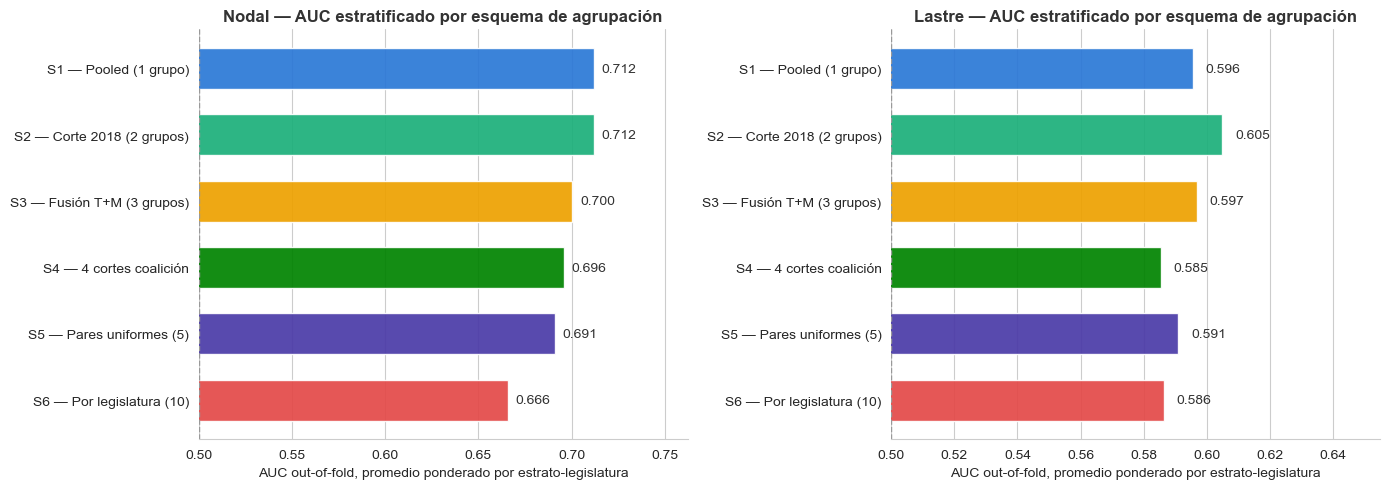

In [12]:
# --- Figura A: AUC ponderado por legislaturas, por esquema (nodal | lastre) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, res, ttl in [(axes[0], res_nodal, "Nodal"), (axes[1], res_lastre, "Lastre")]:
    vals = res["Pond. legis"].values
    ypos = np.arange(len(SCHEME_ORDER))[::-1]
    bars = ax.barh(ypos, vals, height=0.62, color=SCHEME_COLORS, alpha=0.92)
    for yp, v in zip(ypos, vals):
        ax.text(v + 0.004, yp, f"{v:.3f}", va="center", fontsize=10, color=TXT)
    ax.set_yticks(ypos)
    ax.set_yticklabels([SCHEME_SHORT[s] for s in SCHEME_ORDER], fontsize=10)
    ax.set_xlim(0.5, max(vals) + 0.05)
    ax.axvline(0.5, color="#999999", lw=1, ls="--")
    ax.set_xlabel("AUC out-of-fold, promedio ponderado por estrato-legislatura")
    ax.set_title(f"{ttl} — AUC estratificado por esquema de agrupación",
                 fontsize=12, fontweight="bold", color=TXT)
    ax.grid(axis="y", visible=False)
    sns.despine(ax=ax, left=True)
plt.tight_layout()
plt.show()


**Cómo leer la Figura A.** Barras horizontales = AUC ponderado por estrato-legislatura (`Pond. legis`) de cada esquema; la línea discontinua en 0.5 marca el azar. Para **nodal** las barras se agolpan en una banda estrecha: visualmente, la elección de agrupación apenas mueve la discriminación agregada. Para **lastre** las barras están más abajo y aún más planas, confirmando que ese target es poco separable. El mensaje de la figura es que la elección de segmentación apenas mueve la predicción agregada entre 1 y 5 grupos — la **brecha material aparece solo en el extremo fino**: S6 es el único claramente rezagado.


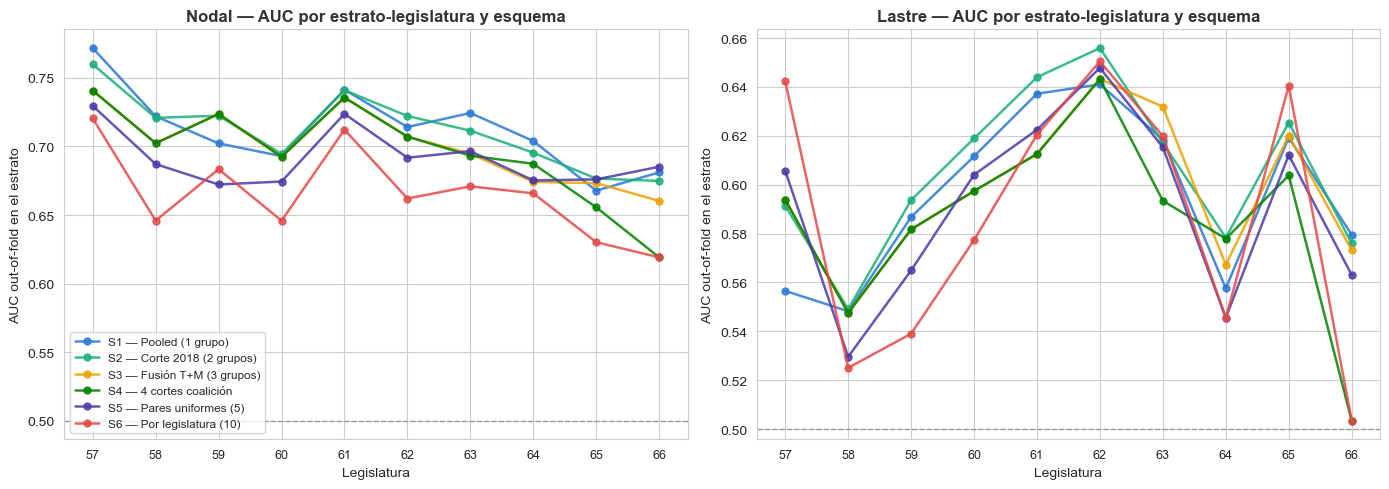

In [13]:
# --- Figura B: AUC por estrato-legislatura, una línea por esquema ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
xt = np.arange(len(LEGIS))
for ax, res_leg, ttl in [(axes[0], res_nodal_leg, "Nodal"),
                         (axes[1], res_lastre_leg, "Lastre")]:
    for i, sch in enumerate(SCHEME_ORDER):
        y = [res_leg.loc[SCHEME_SHORT[sch], f"LEG {l}"] for l in LEGIS]
        ax.plot(xt, y, marker="o", ms=5, lw=1.8, alpha=0.85,
                color=SCHEME_COLORS[i], label=SCHEME_SHORT[sch])
    ax.set_xticks(xt)
    ax.set_xticklabels([str(l) for l in LEGIS], fontsize=9)
    ax.axhline(0.5, color="#999999", lw=1, ls="--")
    ax.set_xlabel("Legislatura")
    ax.set_ylabel("AUC out-of-fold en el estrato")
    ax.set_title(f"{ttl} — AUC por estrato-legislatura y esquema",
                 fontsize=12, fontweight="bold", color=TXT)
axes[0].legend(fontsize=8.5, loc="lower left", frameon=True)
plt.tight_layout()
plt.show()


**Cómo leer la Figura B.** Cada línea es un esquema recorriendo los 10 estratos-legislatura (57–66); ningún esquema va resaltado — la figura compara a los seis candidatos en pie de igualdad. Donde las líneas se **superponen**, la agrupación es irrelevante: todos ordenan igual de bien a los diputados de esa legislatura. Donde se **abren en abanico**, los esquemas difieren; en particular, las legislaturas donde los esquemas con grupos de una sola legislatura (S6 en toda la serie, S4 en la LXVI) caen respecto a los gruesos delatan la **penalización por varianza** de entrenar con n≈500. La lectura completa del patrón está en §6.1.


## 6.1 Interpretación — targets binarios

**Panorama.** El AUC ponderado por estrato-legislatura (`Pond. legis`, LR L1+SFM) ordena así las segmentaciones:

| Esquema | Nodal | Lastre |
|---|---:|---:|
| S2 — Corte 2018 | **0.712** | **0.605** |
| S1 — Pooled | 0.712 | 0.596 |
| S3 — Fusión T+M | 0.700 | 0.597 |
| S4 — 4 cortes coalición | 0.696 | 0.585 |
| S5 — Pares uniformes | 0.691 | 0.591 |
| S6 — Por legislatura | 0.666 | 0.586 |

Cuatro lecturas:

**1. Entre 1 y 5 grupos, las diferencias predictivas son sub-resolución — empate según la regla de §5.7.** La banda S1–S5 abarca 0.021 puntos de AUC en nodal (0.691–0.712) y 0.020 en lastre (0.585–0.605), en el orden del umbral de empate (≈±0.02). El desagregado por legislatura muestra que en las legislaturas 57–62 los candidatos de esa banda rinden a la par (en la LEG 59, S4 incluso encabeza: 0.724 vs. 0.702 del pooled). **Las diferencias se concentran en las legislaturas 63–66**, sobre todo en la LXVI: nodal 0.681 (S1) vs. 0.619 (S4); lastre 0.580 vs. 0.503.

**2. La penalización del extremo fino es varianza pura.** S6 es el peor candidato en ambos targets (0.666/0.586) y en casi todos los estratos, y S4 reproduce el mismo síntoma exactamente donde su grupo se reduce a una legislatura (LXVI, n=500). La vista *naive* lo corrobora: los AUC nodal por legislatura oscilan de 0.619 a 0.724 con desviaciones de hasta ±0.071. Más homogeneidad no compensa el costo muestral de bajar a n≈500: el intercambio sesgo-varianza tiene un límite duro por el lado fino.

**3. A granularidad comparable, la ubicación de las fronteras no mueve la predicción.** S4 (fronteras políticas, n=500–1,500) supera a S5 (ventanas mecánicas, n=1,000) por solo 0.005 en nodal (0.696 vs. 0.691) y queda 0.006 por debajo en lastre (0.585 vs. 0.591). La capacidad predictiva estratificada distingue **granularidades**, no familias: la evidencia sobre si las fronteras políticas son mejores que las mecánicas debe venir del análisis estructural (§8), no del AUC.

**4. El mejor candidato compacto es S2 — con una reserva de sesgo.** S2 encabeza lastre (0.605) y empata con el pooled en nodal (0.712). Su vista *naive* muestra, sin embargo, que el grupo `POST_2018` (LXIV–LXVI, n=1,500) alcanza solo 0.687 dentro de grupo frente a 0.730 del `PRE_2018`: el corte único junta legislaturas con dinámicas distintas en su tramo final — heterogeneidad interna que la sección 8 examina con los coeficientes.

**Nota sobre el AUC global.** Para S1 el AUC global (0.728) supera al estratificado (0.712): esa brecha es exactamente el crédito por tasas base entre periodos descrito en §4, y es la razón por la que la comparación honesta debe hacerse dentro de estratos fijos por legislatura. La columna de robustez (LR L1 completo, sin SFM) replica el ordenamiento en ambos targets (S1/S2 arriba con 0.712/0.711 en nodal, S6 abajo con 0.676).

# 7. Resultados — comisiones temáticas (GLM Poisson)

Mismo protocolo OOF con el GLM Poisson (`StandardScaler` → `PoissonRegressor(alpha=1.0)`), evaluado con **MAE** (menor = mejor) sobre los mismos estratos fijos. El MAE es directamente comparable entre esquemas porque está en la escala del conteo.

In [14]:
# --- OOF Poisson por esquema + tabla ---
rows = []
for sch in SCHEME_ORDER:
    oof = oof_predict(SCHEMES[sch], "n_comisiones_tematicas", lr_poisson,
                      is_binary=False)
    per_leg, w_leg = strat_mae(oof, "n_comisiones_tematicas", "legis_str")
    rows.append({
        "Esquema": SCHEME_SHORT[sch],
        **{f"LEG {l}": per_leg.get(str(l), np.nan) for l in LEGIS},
        "Pond. legis": w_leg,
    })
res_tem = pd.DataFrame(rows).set_index("Esquema")

# Baseline: predecir la media del estrato-legislatura (sin features)
base_rows, base_ns = {}, []
for l in LEGIS:
    m = df_enc["legislatura_num"] == l
    y = df_enc.loc[m, "n_comisiones_tematicas"]
    base_rows[f"LEG {l}"] = float(np.abs(y - y.mean()).mean())
    base_ns.append(int(m.sum()))
base_w = float(np.average(list(base_rows.values()), weights=base_ns))
res_tem.loc["Baseline (media por legislatura)"] = {**base_rows,
                                                   "Pond. legis": base_w}

print("TEMÁTICAS — MAE out-of-fold por estrato-legislatura (GLM Poisson; menor = mejor)")
display(res_tem.round(3))


TEMÁTICAS — MAE out-of-fold por estrato-legislatura (GLM Poisson; menor = mejor)


,LEG 57,LEG 58,LEG 59,LEG 60,LEG 61,LEG 62,LEG 63,LEG 64,LEG 65,LEG 66,Pond. legis
Esquema,,,,,,,,,,,
S1 — Pooled (1 grupo),0.912,0.738,0.793,0.761,0.752,0.871,0.829,0.767,1.030,0.742,0.819
S2 — Corte 2018 (2 grupos),0.897,0.745,0.798,0.755,0.748,0.848,0.808,0.788,1.037,0.728,0.815
S3 — Fusión T+M (3 grupos),0.872,0.754,0.803,0.757,0.762,0.846,0.824,0.783,1.040,0.723,0.816
S4 — 4 cortes coalición,0.872,0.754,0.803,0.757,0.762,0.846,0.815,0.795,1.044,0.740,0.819
S5 — Pares uniformes (5),0.866,0.772,0.790,0.766,0.757,0.845,0.819,0.768,1.053,0.736,0.817
S6 — Por legislatura (10),0.840,0.737,0.785,0.766,0.763,0.856,0.817,0.789,1.065,0.740,0.816
Baseline (media por legislatura),0.887,0.786,0.830,0.779,0.785,0.896,0.824,0.742,1.102,0.747,0.838


**Lectura — MAE de comisiones temáticas (GLM Poisson).** El MAE está en la **escala del conteo**: un valor de ~0.82 significa que la predicción se aleja, en promedio, ~0.82 comisiones del valor real (menor = mejor). A diferencia del AUC, es directamente comparable entre esquemas porque comparte escala y los mismos 10 estratos-legislatura, sin distorsión por tasa base. La fila **`Baseline (media por legislatura)`** predice la media del estrato **sin usar features** y fija la vara del valor añadido (§5.4); al ser la media del estrato más fino, es una vara más exigente que una media por era.

*Qué dicen los números.* Todos los esquemas caen en 0.815–0.819, apenas por debajo del baseline (0.838): los features aportan solo ~2–3% de mejora, y la **agrupación es indiferente** para este target. Es la evidencia cuantitativa de que el volumen de comisiones temáticas responde a una lógica distributiva que el perfil biográfico no captura (síntesis en §7.1).


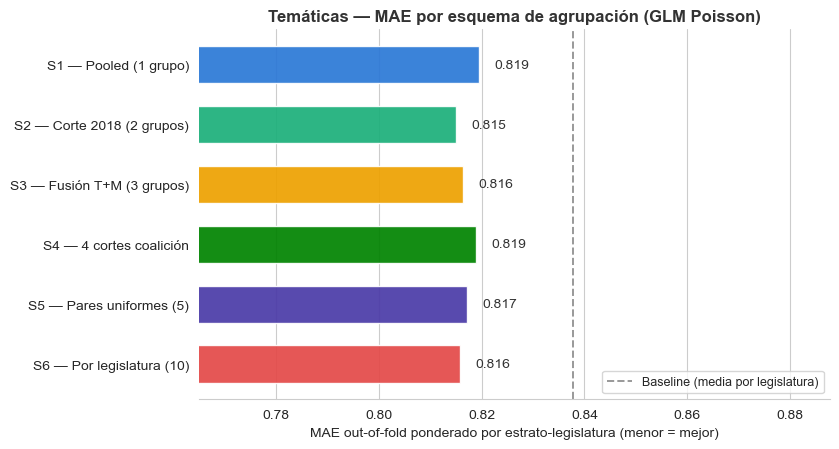

In [15]:
# --- Figura C: MAE ponderado por esquema ---
fig, ax = plt.subplots(figsize=(8.5, 4.6))
vals = res_tem.loc[[SCHEME_SHORT[s] for s in SCHEME_ORDER], "Pond. legis"].values
ypos = np.arange(len(SCHEME_ORDER))[::-1]
ax.barh(ypos, vals, height=0.62, color=SCHEME_COLORS, alpha=0.92)
for yp, v in zip(ypos, vals):
    ax.text(v + 0.003, yp, f"{v:.3f}", va="center", fontsize=10, color=TXT)
ax.axvline(res_tem.loc["Baseline (media por legislatura)", "Pond. legis"],
           color="#999999", lw=1.4, ls="--",
           label="Baseline (media por legislatura)")
ax.set_yticks(ypos)
ax.set_yticklabels([SCHEME_SHORT[s] for s in SCHEME_ORDER], fontsize=10)
ax.set_xlabel("MAE out-of-fold ponderado por estrato-legislatura (menor = mejor)")
ax.set_title("Temáticas — MAE por esquema de agrupación (GLM Poisson)",
             fontsize=12, fontweight="bold", color=TXT)
ax.set_xlim(min(vals) - 0.05, max(max(vals), base_w) + 0.05)
ax.legend(fontsize=9, loc="lower right", frameon=True)
ax.grid(axis="y", visible=False)
sns.despine(ax=ax, left=True)
plt.tight_layout()
plt.show()


**Cómo leer la Figura C.** Barras = MAE ponderado por estrato-legislatura de cada esquema; la línea discontinua es el *baseline* de "predecir la media de la legislatura" sin usar features. Todas las barras se agolpan apenas a la izquierda del baseline y entre sí: mejora **marginal y plana**. La figura hace visible de un vistazo la conclusión de §7.1 — para las temáticas, ningún esquema de agrupación mueve la aguja.


## 7.1 Interpretación — temáticas

El MAE ponderado es **plano entre segmentaciones**: de 0.815 (S2) a 0.819 (S1 y S4), una banda de 0.004 comisiones — ruido. Ninguna segmentación mejora el baseline de "predecir la media de la legislatura" (0.838) en más de ~2.7%, y en la LEG 64 el baseline incluso supera a los seis esquemas (0.742 vs. 0.767–0.795). El conteo de comisiones temáticas es **insensible a la segmentación temporal**: el perfil biográfico apenas aporta señal para este target, se agrupe como se agrupe. Conforme a la regla de §5.7, este target no discrimina entre candidatos y queda fuera del veredicto de §9.

# 8. Validez estructural — heterogeneidad de coeficientes entre legislaturas

El AUC mide cuánto predice cada segmentación; esta sección mide si sus **fronteras caen donde de verdad cambia la lógica de asignación**. Para cada candidato la prueba es la misma: si su partición es estructuralmente válida, los vectores de coeficientes de una LR L1 ajustada **por legislatura** deben parecerse más *dentro* de sus grupos que *entre* ellos (estructura de bloques). Se ajusta `lr_binary` (L1 completo, sin SFM, para que los 61 coeficientes sean comparables posición a posición) sobre `nodal_bin` en cada legislatura, excluyendo `legislatura_num` del espacio de features (constante dentro de cada grupo), y se calcula la **similitud coseno** entre los 10 vectores.

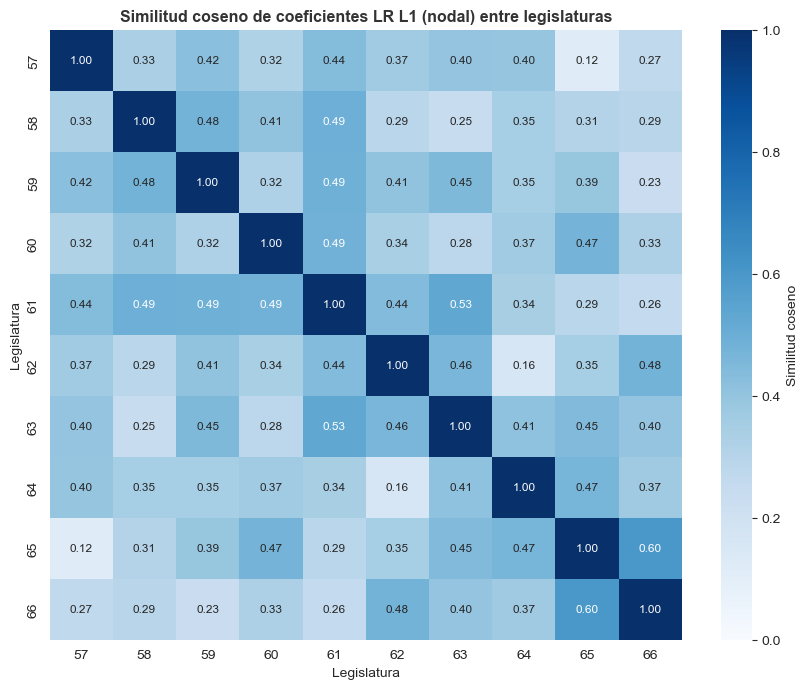

In [16]:
# --- Matriz de similitud coseno entre legislaturas (nodal) ---
FEATS_NOLEG = [f for f in FEAT_COLS if f != "legislatura_num"]
coefs = {}
for l in LEGIS:
    m = df_enc["legislatura_num"] == l
    X = df_enc.loc[m, FEATS_NOLEG].astype(float)
    y = df_enc.loc[m, "nodal_bin"].astype(float)
    pipe = Pipeline([("sc", StandardScaler()),
                     ("lr", LogisticRegression(**_L1_PARAMS))]).fit(X, y)
    coefs[l] = pipe.named_steps["lr"].coef_.ravel()
C = np.vstack([coefs[l] for l in LEGIS])
S = cosine_similarity(C)

fig, ax = plt.subplots(figsize=(8.6, 7))
sns.heatmap(S, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1,
            xticklabels=LEGIS, yticklabels=LEGIS, ax=ax,
            annot_kws={"fontsize": 8.5}, cbar_kws={"label": "Similitud coseno"})
ax.set_title("Similitud coseno de coeficientes LR L1 (nodal) entre legislaturas",
             fontsize=11.5, fontweight="bold", color=TXT)
ax.set_xlabel("Legislatura"); ax.set_ylabel("Legislatura")
plt.tight_layout()
plt.show()

**Lectura — heatmap de similitud coseno de coeficientes.** Cada celda es la similitud coseno (0–1) entre los vectores de 61 coeficientes de la LR L1 ajustada en dos legislaturas: **1 = misma lógica de asignación**, 0 = ortogonal. La matriz no resalta las fronteras de ningún candidato: la estructura de bloques de cada segmentación se cuantifica de forma neutral en la tabla siguiente, que calcula la similitud dentro vs. entre grupos para los seis candidatos por igual. *Advertencia de estabilidad:* los coeficientes L1 ajustados con n≈500 por legislatura tienen varianza alta, y los valores finos de la matriz varían entre corridas/entornos; las comparaciones celda a celda no deben sobreinterpretarse — es la manifestación directa del criterio de **varianza** de §1.

*Relevancia para el análisis.* Este diagnóstico responde una pregunta que el AUC **no puede** contestar: no *cuánto* predice cada segmentación, sino **si sus fronteras caen donde de verdad cambia el mecanismo** de asignación. Opera sobre los **coeficientes** (la lógica del modelo), no sobre las predicciones (su desempeño); por eso es el instrumento que mide la validez estructural (§5.5).

In [17]:
# --- Similitud media dentro vs. entre grupos, por esquema ---
def block_similarity(mapping):
    "Similitud coseno media dentro de grupos vs. entre grupos (pares i<j)."
    within, between = [], []
    for i, li in enumerate(LEGIS):
        for j, lj in enumerate(LEGIS):
            if j <= i:
                continue
            (within if mapping[li] == mapping[lj] else between).append(S[i, j])
    w = float(np.mean(within)) if within else np.nan
    b = float(np.mean(between)) if between else np.nan
    return w, b

rows = []
for sch in SCHEME_ORDER:
    w, b = block_similarity(SCHEMES[sch])
    rows.append({"Esquema": SCHEME_SHORT[sch],
                 "Sim. dentro de grupo": w, "Sim. entre grupos": b,
                 "Δ (dentro − entre)": (w - b) if not (np.isnan(w) or np.isnan(b))
                                        else np.nan})
df_block = pd.DataFrame(rows).set_index("Esquema")
print("Cohesión de coeficientes por esquema (mayor Δ = la partición agrupa")
print("legislaturas con lógica de asignación más parecida):")
display(df_block.round(3))

Cohesión de coeficientes por esquema (mayor Δ = la partición agrupa
legislaturas con lógica de asignación más parecida):


,Sim. dentro de grupo,Sim. entre grupos,Δ (dentro − entre)
Esquema,,,
S1 — Pooled (1 grupo),0.375,NaN,NaN
S2 — Corte 2018 (2 grupos),0.411,0.334,0.076
S3 — Fusión T+M (3 grupos),0.434,0.354,0.080
S4 — 4 cortes coalición,0.426,0.362,0.064
S5 — Pares uniformes (5),0.421,0.369,0.052
S6 — Por legislatura (10),NaN,0.375,NaN


**Lectura — cohesión de coeficientes (Δ = dentro − entre).** Para cada segmentación se promedia la similitud coseno **dentro** de sus grupos y **entre** grupos; **Δ** es su diferencia. Un Δ grande significa que la partición traza sus fronteras justo donde la lógica de coeficientes cambia (bloques internamente parecidos, contraste alto hacia afuera). S1 y S6 muestran `NaN` porque, por construcción, no tienen pares entre-grupos (un solo grupo) o dentro-de-grupo (grupos de una legislatura), respectivamente.

*Cómo leerla con cautela.* En esta corrida, S3 alcanza el Δ máximo (0.080), seguido de cerca por S2 (0.076); S4 queda en 0.064 y S5 claramente abajo (0.052). La banda de cortes políticos es estrecha y su orden fino **no es estable entre corridas**: ejecuciones previas de este mismo cuaderno, con entornos ligeramente distintos, colocaban primero a S2 (0.086) o a S4 (0.089). Lo robusto no es el ranking dentro de la banda, sino el **contraste entre la familia de cortes políticos (Δ 0.064–0.080) y las ventanas uniformes ciegas a la política (0.052)**. La interpretación está en §8.1.

## 8.1 Interpretación — validez estructural

Este análisis pregunta algo distinto al AUC: no *cuánto* predice cada segmentación, sino **si sus fronteras cortan donde de verdad cambia la lógica de asignación**. El indicador Δ (similitud media dentro de grupo − entre grupos) mide la calidad estructural de cada partición:

| Esquema | Sim. dentro | Sim. entre | Δ |
|---|---:|---:|---:|
| S3 — Fusión T+M | **0.434** | 0.354 | **0.080** |
| S2 — Corte 2018 | 0.411 | 0.334 | 0.076 |
| S4 — 4 cortes coalición | 0.426 | 0.362 | 0.064 |
| S5 — Pares uniformes | 0.421 | 0.369 | 0.052 |

Tres lecturas:

- **La familia política maximiza la validez estructural.** Los tres candidatos cuyas fronteras siguen cambios de coalición dominante (S2, S3, S4) se agrupan en Δ 0.064–0.080, por encima de las ventanas uniformes de S5 (0.052), que parten los bloques reales por la mitad. Las fronteras electorales (2006, 2015, 2018, 2024) capturan cambios reales del mecanismo; las mecánicas, no. Este contraste — no el orden fino dentro de la banda política — es el hallazgo estructural robusto.
- **En esta corrida, S3 encabeza la validez estructural.** Sus tres grupos (cortes en 2006 y 2015) logran el mayor Δ (0.080) y la mayor cohesión interna (0.434); S2 queda a solo 0.004 (Δ=0.076). En ejecuciones previas del mismo cuaderno el primer lugar lo ocupaban S2 (0.086) o S4 (0.089): el orden fino **rota entre corridas** y ninguna conclusión debe descansar en él. Lo que sí se repite en todas las corridas es que las fronteras de coalición (2006, 2015, 2018) aparecen en la banda alta y S5 queda último.
- **La fragilidad del orden fino es varianza en acción.** Los coeficientes L1 por legislatura se estiman con n≈500 — el mismo cuello muestral que castiga a S6 en predicción hace inestables los valores finos de Δ. Es la razón por la que la regla de decisión (§5.7) lee este criterio al nivel de familias, no de ranking.

La similitud media global entre los 10 vectores de coeficientes es 0.375 — lejos de 1.0: la lógica de asignación nodal **no** es estable a lo largo de las diez legislaturas. Es la evidencia directa de **sesgo** contra el candidato sin segmentación: S1, aunque predice bien en promedio, estima un mecanismo que no corresponde a ningún periodo en particular.

# 9. Conclusiones — la segmentación temporal óptima

## 9.1 Aplicación de la regla de decisión (§5.7)

| Candidato | Predicción (`Pond. legis` nodal / lastre) | Validez estructural (Δ) | Sesgo (heterogeneidad interna) | Varianza (n por grupo) | Estado |
|---|---|---|---|---|---|
| S1 — Pooled | 0.712 / 0.596 (empate, banda alta) | n/d (sin fronteras) | Máximo: similitud global 0.375 → estima un promedio de regímenes que no existió | Mínima (n=5,000) | Descartado por sesgo |
| S2 — Corte 2018 | **0.712 / 0.605** (encabeza o empata) | 0.076 | Moderado: `POST_2018` naive 0.687 vs. 0.730 de `PRE_2018` | Baja (n=3,500/1,500) | **Frontera óptima (predicción)** |
| S3 — Fusión T+M | 0.700 / 0.597 (empate) | **0.080** (máx.); cohesión interna máx. (0.434) | Bajo | Media (n=1,500–2,000) | **Frontera óptima (estructura)** |
| S4 — 4 cortes coalición | 0.696 / 0.585 (empate) | 0.064 | Bajo | Alta en su grupo final (n=500, naive 0.619±0.059) | Eficiente, con castigo de varianza al final |
| S5 — Pares uniformes | 0.691 / 0.591 (empate) | 0.052 (mín. de los comparables) | — | Media (n=1,000) | Descartado por validez estructural |
| S6 — Por legislatura | 0.666 / 0.586 (peor) | n/d | Mínimo | Máxima (n≈500, σ hasta ±0.071) | Descartado por varianza |

Los extremos caen cada uno por su criterio: S6 por varianza (peor predicción de todo el espacio), S1 por sesgo (predice en banda alta, pero sus coeficientes promedian regímenes con similitud media de solo 0.375), y S5 por validez estructural (granularidad comparable a S4, fronteras en el lugar equivocado). La frontera eficiente del intercambio queda en la familia de cortes políticos de granularidad baja: **S2 y S3**, con S4 justo detrás (paga la varianza de aislar la última legislatura con n=500).

## 9.2 Veredicto

**La segmentación óptima es un corte político de granularidad baja; en esta evaluación, la frontera eficiente se reduce a dos candidatos: S2 (corte único en 2018) y S3 (tres tramos con cortes en 2006 y 2015).**

- **S2** gana si la capacidad predictiva manda: encabeza lastre (0.605), empata el mejor nodal (0.712) y, con solo dos grupos (n=3,500/1,500), es el candidato de menor varianza de la familia política. Su costo: heterogeneidad interna del grupo `POST_2018` (AUC naive 0.687 vs. 0.730 del anterior) — sesgo residual.
- **S3** gana si la validez estructural manda: máximo Δ de esta corrida (0.080), máxima cohesión interna (0.434), predicción dentro del umbral de empate con S2 (−0.012 nodal, −0.008 lastre). Ofrece más resolución temporal con grupos internamente más homogéneos.

Reserva transversal: el orden fino de Δ dentro de la familia política **rota entre corridas** (S4 0.089 y S2 0.086 en ejecuciones previas; S3 0.080 en esta). El veredicto **fuerte** — estable en todas las corridas — es que la segmentación óptima usa cortes políticos con 2–4 grupos, y que los extremos y las ventanas mecánicas quedan descartados. El veredicto **débil** — específico de esta ejecución — es la preferencia puntual por S2 (predicción) o S3 (estructura).

## 9.3 Respuesta directa a la pregunta del cuaderno

La división de segmentos de tiempo que minimiza sesgo y varianza mientras maximiza capacidad predictiva y validez estructural, con LR Lasso, es **una partición de granularidad baja (2–3 grupos) cuyas fronteras siguen los cambios de coalición dominante: el corte único en la elección de 2018 si se prioriza la capacidad predictiva, o los tres tramos con cortes en 2006 y 2015 si se prioriza la validez estructural** — ambos estadísticamente empatados en predicción. Los extremos fallan por construcción — sin segmentar, el modelo estima un promedio de mecanismos que no existió (sesgo, similitud global 0.375); por legislatura, el ruido muestral domina (varianza) — y las ventanas ciegas a la política fallan por validez estructural: a igual granularidad, trazar las fronteras en los años de cambio de coalición produce bloques de coeficientes más cohesivos que trazarlas mecánicamente.

## 9.4 Limitaciones y extensiones

- **Una sola corrida para la evidencia estructural.** El Δ de §8 proviene de una ejecución con una semilla; su orden fino es inestable entre corridas. Extensión natural: *bootstrap* o multi-semilla sobre los coeficientes por legislatura para poner intervalos alrededor de Δ y convertir la preferencia S2/S3 en una afirmación con incertidumbre cuantificada.
- **Espacio de candidatos discreto y pequeño.** Se evaluaron 6 segmentaciones de las 512 particiones contiguas posibles de 10 legislaturas. Una búsqueda exhaustiva con el mismo protocolo (OOF + estratos-legislatura) es computacionalmente factible y convertiría el veredicto en un óptimo global, no solo en el mejor de seis.
- **El grupo final corto.** Cualquier segmentación que aísle la última legislatura hereda n=500; un modelo jerárquico con *partial pooling* entre segmentos permitiría resolución fina sin pagar toda la varianza. Con datos de la próxima legislatura (2027), el tramo posterior a 2018/2024 podrá reevaluarse con más muestra.
- **Las temáticas no discriminan.** El conteo de comisiones temáticas es insensible a la segmentación (banda MAE 0.815–0.819 vs. baseline 0.838) y no participa del veredicto; la conclusión aplica a los targets binarios.